# Spatial Analysis of Real Estate Prices in Paris

New public databases provide access to the universe of French real estate transactions (notary database, DV3F) with information on price, area, and location. The objective of this project is to offer a highly localized analysis of housing price variability in Paris and to understand the high degree of intra-arrondissement heterogeneity.

Data sources:
- **DVF+ Open Data (Cerema)**: real estate transactions in Paris, department 75.
- **Etalab / data.gouv.fr**: geocoded DVF reference data (coordinates of cadastral parcels).
- **Open Data Paris**: administrative boundaries of the arrondissements (GeoJSON format).

Plan:
1. **Phase 1**: DVF cleaning (aggregation by `idmutation`, filters on off-plan sales (VEFA), typology, price bounds), descriptive statistics by arrondissement, visualization of intra-arrondissement dispersion, structural control of the effect of area on price per sq.m (Spearman correlation).
2. **Phase 2**: scaling down to the cadastral section, variance decomposition (adjusted R²) by OLS with geographical dummies.
3. **Phase 3**: geocoding via Etalab, constrained spatial regionalization (Ward's method and k-NN neighborhood graph on centroids), cartographic comparison with current INSEE administrative boundaries.
4. **Phase 4**: integration of external variables from Paris open data (green spaces, transport, trees, public facilities, noise) to identify external determinants that explain the residual price variance not captured by pure geography.
---
Tech stack: pandas, numpy, scipy, matplotlib, seaborn, scikit-learn, statsmodels, folium.

# Spatial Analysis of Real Estate Prices in Paris

New public databases provide access to the universe of French real estate transactions (notary database, DV3F) with information on price, area, and location. The objective of this project is to offer a highly localized analysis of housing price variability in Paris and to understand the high degree of intra-arrondissement heterogeneity.

Data sources:
- **DVF+ Open Data (Cerema)** : real estate transactions in Paris, department 75.
- **Etalab / data.gouv.fr** : geocoded DVF reference data (coordinates of cadastral parcels).
- **Open Data Paris** : administrative boundaries of the arrondissements (GeoJSON format).

Plan:
1. **Phase 1**: DVF cleaning (aggregation by `idmutation`, filters on off-plan sales (VEFA), typology, price bounds), descriptive statistics by arrondissement, and visualization of intra-arrondissement dispersion.
2. **Phase 2**: Geographical downscaling to the cadastral section and variance decomposition (adjusted R²) via OLS regression with geographical dummies.
3. **Phase 3**: Geocoding via Etalab, constrained spatial regionalization (Ward's method and k-NN neighborhood graph), and cartographic comparison with current INSEE administrative boundaries.
4. **Phase 4**: Multi-year data massification (2021-2024) and justification for the optimal number of clusters via the economic elbow method and spatial separation metrics.

---
Tech stack: pandas, numpy, scipy, matplotlib, seaborn, scikit-learn, statsmodels, folium.

# Phase 1: Variability of Real Estate Prices in Paris by Arrondissement

**Objective:** Analyze the heterogeneity of real estate prices in Paris using DVF (Demandes de Valeurs Foncières) data.
We focus on importing, cleaning the raw sample, and computing the first descriptive statistics by arrondissement.

## 1. Environment Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

pd.set_option('display.max_columns', 50)

df = pd.read_csv("mutations_d75.csv", sep=";")

df.head(3)

,idmutation,idmutinvar,idopendata,idnatmut,codservch,refdoc,datemut,anneemut,moismut,coddep,libnatmut,vefa,valeurfonc,nbdispo,nblot,nbcomm,l_codinsee,nbsection,l_section,nbpar,l_idpar,nbparmut,l_idparmut,nbsuf,sterr,...,nbapt2pp,nbapt3pp,nbapt4pp,nbapt5pp,nbmai1pp,nbmai2pp,nbmai3pp,nbmai4pp,nbmai5pp,sbati,sbatmai,sbatapt,sbatact,sapt1pp,sapt2pp,sapt3pp,sapt4pp,sapt5pp,smai1pp,smai2pp,smai3pp,smai4pp,smai5pp,codtypbien,libtypbien
0,12720526,b5b875cc3e82afbe1559b1bbeab6157f,b5b875cc3e82afbe1559b1bbeab6157f,2,NaN,NaN,2014-10-30,2014,10,75,Vente en l'état futur d'achèvement,True,360000.0,1,1,1,['75119'],1,['AO'],1,['75119000AO0086'],0,NaN,0,0.0,...,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101,BATI - INDETERMINE : Vefa sans descriptif
1,12738160,120ee7765ec5c132c3ad1394fb4eb803,120ee7765ec5c132c3ad1394fb4eb803,2,NaN,NaN,2014-04-24,2014,4,75,Vente en l'état futur d'achèvement,True,334000.0,1,1,1,['75114'],1,['CY'],1,['75114000CY0059'],0,NaN,0,0.0,...,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101,BATI - INDETERMINE : Vefa sans descriptif
2,12739989,58195de5cc7c8af9065123a10921548e,58195de5cc7c8af9065123a10921548e,2,NaN,NaN,2014-06-06,2014,6,75,Vente en l'état futur d'achèvement,True,369420.0,1,1,1,['75114'],1,['CY'],1,['75114000CY0059'],0,NaN,0,0.0,...,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,101,BATI - INDETERMINE : Vefa sans descriptif


## 2. Need to Clean and Restrict the Sample

The raw sample contains the complete universe of transactions. To obtain a relevant price per sq.m, several processing steps are essential:
1. **Basic filters:** We must only keep standard "sales" of apartments (excluding off-plan sales/VEFA, land, and commercial premises).
2. **Transaction aggregation:** In the DVF database, a transaction comprising several lots generates multiple rows, but the overall property value is repeated on each row. We must therefore group the data by `idmutation` (the transaction) to sum the areas before calculating the price, otherwise the results will be biased.

In [2]:
# Basic filters
df_clean = df[
    (df['libnatmut'] == 'Vente') & 
    (df['vefa'] == False) &
    (df['libtypbien'].str.contains('APPARTEMENT', na=False)) &
    (df['valeurfonc'] > 0) & 
    (df['sbati'] >= 9)
].copy()

# Aggregation by transaction (idmutation)
df_clean = df_clean.groupby('idmutation').agg({
    'valeurfonc': 'first',
    'sbati': 'sum',
    'l_codinsee': 'first',
    'anneemut': 'first',
    'l_section': 'first',
    'l_idpar' : 'first'
}).reset_index()

# Calculation of price per sq.m
df_clean['prix_m2'] = df_clean['valeurfonc'] / df_clean['sbati']

# Removal of statistical outliers (data entry errors)
df_clean = df_clean[
    (df_clean['prix_m2'] > 1000) & 
    (df_clean['prix_m2'] < 30000)
]

print(f"Number of transactions before cleaning: {len(df)}")
print(f"Number of viable transactions after cleaning: {len(df_clean)}")

Number of transactions before cleaning: 457097
Number of viable transactions after cleaning: 337417


## 3. Global Descriptive Statistics

Now that the bias of partial areas and entry errors has been removed, we can calculate descriptive statistics for the entire city.

In [3]:
print("--- Global Statistics (Paris) ---")
print("Average price per sq.m:", round(df_clean['prix_m2'].mean(), 2), "€")
print("Median price per sq.m:", round(df_clean['prix_m2'].median(), 2), "€")
print("Minimum price per sq.m:", round(df_clean['prix_m2'].min(), 2), "€")
print("Maximum price per sq.m:", round(df_clean['prix_m2'].max(), 2), "€")

--- Global Statistics (Paris) ---
Average price per sq.m: 9730.55 €
Median price per sq.m: 9500.0 €
Minimum price per sq.m: 1000.71 €
Maximum price per sq.m: 29975.0 €


## 4. Spatial Heterogeneity: Inter-Arrondissement Analysis

In preparation for the spatial analysis required by the project, we format the geographical codes (INSEE) to extract the arrondissement number. We then calculate the average price per geographical sector to observe initial disparities.

--- Summary Table by Arrondissement ---


,Nb_Sales,Avg_Area_sqm,Avg_Price_sqm,Median_Price_sqm
arrondissement,,,,
1,3412,58.0,11943.0,11587.0
2,5130,48.0,10698.0,10725.0
3,7296,53.0,11330.0,11251.0
4,5442,57.0,12278.0,12092.0
5,8945,53.0,11553.0,11522.0
6,8430,69.0,13722.0,13422.0
7,9815,84.0,13551.0,13056.0
8,7526,94.0,11598.0,11227.0
9,12420,59.0,10256.0,10259.0


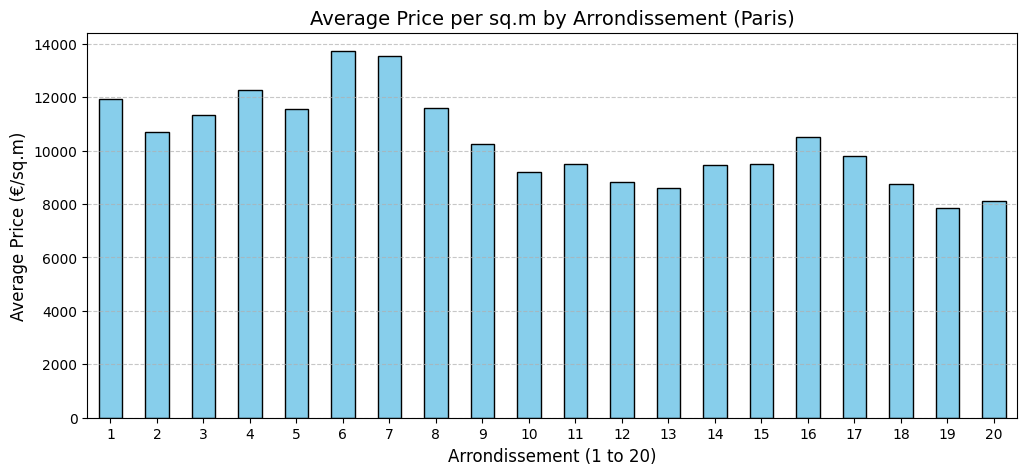

In [4]:
# Arrondissement cleaning
def extract_arrondissement_number(value):
    try:
        code = ast.literal_eval(value)[0]
        return int(code[-2:])
    except:
        return None

df_clean['arrondissement'] = df_clean['l_codinsee'].apply(extract_arrondissement_number)
df_clean = df_clean.dropna(subset=['arrondissement']) 

# Descriptive table by arrondissement
resume_arrondissement = df_clean.groupby('arrondissement').agg(
    Nb_Sales=('idmutation', 'count'),          # Volume
    Avg_Area_sqm=('sbati', 'mean'),            # Typology
    Avg_Price_sqm=('prix_m2', 'mean'),         # Price
    Median_Price_sqm=('prix_m2', 'median')     # Median price
).round(0)

print("--- Summary Table by Arrondissement ---")
display(resume_arrondissement)
print("\n")

# Bar chart of average prices
plt.figure(figsize=(12, 5))
resume_arrondissement['Avg_Price_sqm'].plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Average Price per sq.m by Arrondissement (Paris)', fontsize=14)
plt.ylabel('Average Price (€/sq.m)', fontsize=12)
plt.xlabel('Arrondissement (1 to 20)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

plt.show()

## 5. Intra-Arrondissement Dispersion

The average observed earlier smooths out variations. We can also observe the price dispersion within each arrondissement as a boxplot, which brings us closer to our main focus for the rest of the project.

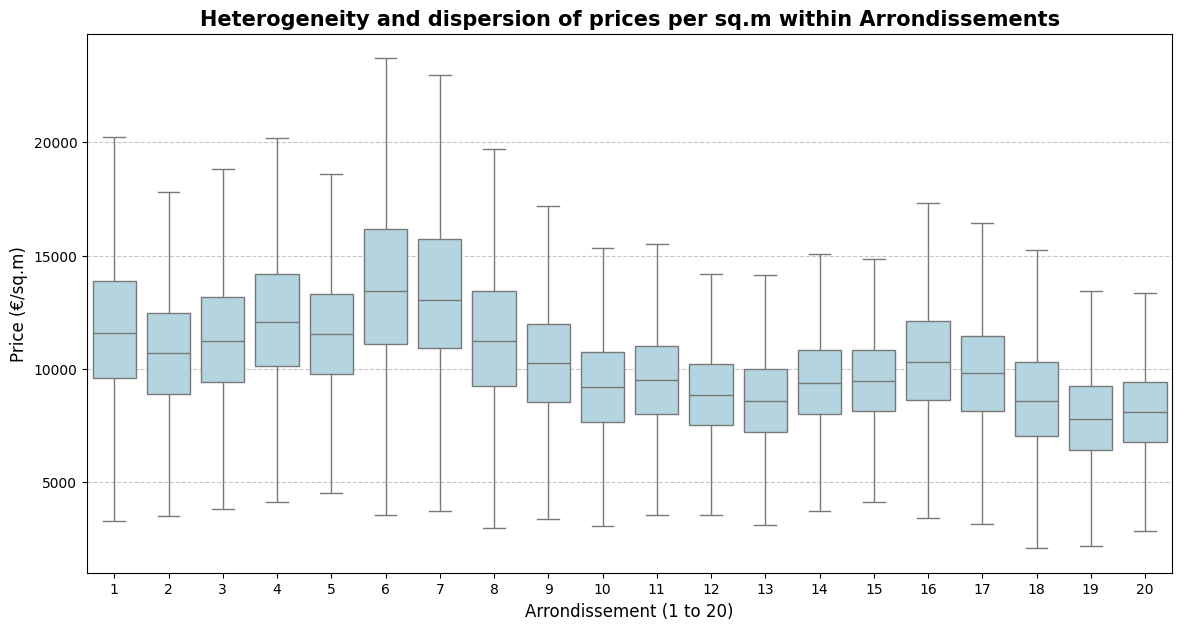

In [5]:
# Boxplot
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_clean, 
    x='arrondissement', 
    y='prix_m2', 
    color='lightblue', 
    showfliers=False # Outliers are hidden for readability
)

plt.title('Heterogeneity and dispersion of prices per sq.m within Arrondissements', fontsize=15, fontweight='bold')
plt.ylabel('Price (€/sq.m)', fontsize=12)
plt.xlabel('Arrondissement (1 to 20)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Conclusion of Phase 1

1. **Methodological necessity:** The exploitation of raw DVF data requires strict reprocessing (exclusion of off-plan sales (VEFA), aggregation by transaction) to ensure the reliability of the "price per sq.m" variable. Even the applied processing is not foolproof: the price bounds we use to filter are arbitrary, and we might be removing too many or too few.
2. **A dual heterogeneity:** The results confirm a strong inter-arrondissement disparity, but above all, a very high variance **even within** certain arrondissements (visible in the spread of the boxplots).
3. **Perspectives:** To understand the origin of this local heterogeneity (proximity to transport, green spaces, noise...), it will be necessary to shift to a micro-local approach, using finer geographical coordinates (200m grids, IRIS).

## Methodological remarks and limitations of the exercise

Cleaning the database led to the exclusion of approximately 26% of the initial observations (going from ~457k raw rows to ~337k viable transactions). This "purge" allowed for the removal of:
- Aberrant or incomplete data (e.g., off-plan sales (VEFA) with unbuilt areas not yet declared).
- "Non-significant" transactions in the residential housing market (cellars, parking spaces, commercial premises, land).
- Symbolic, intra-family sales or exchanges (e.g., transactions listed at €1 or at unrealistic prices per sq.m).
- Micro-areas (under 9 sq.m), whose price per sq.m dynamics are speculative and disconnected from the traditional housing market.

# Phase 2: Intra-arrondissement Variance and Micro-Entities

**Objective:** Address the issue of spatial heterogeneity by verifying whether smaller geographical "sub-entities" better explain price variance than INSEE's administrative boundaries. Our methodology is threefold:

1. **Temporal control:** Because real estate is subject to inflation and cycles, we isolate the year with the highest number of transactions. This allows us to compare constant prices and ensure that the measured variance is indeed geographical, not temporal.
2. **The "Micro-Neighborhood" proxy:** In the absence of exact XY coordinates in the data, we exploit the **Cadastral Section** (`l_section`). The cadastre divides each arrondissement into sections (convex groupings of a few blocks or streets). This is the natural micro-local entity.
3. **Dispersion analysis:** We will compare the standard deviation (dispersion) of prices within the overall arrondissements with that observed within these cadastral sections.

In [6]:
import numpy as np

# 1. Temporal filter: neutralizing the market cycle
annees_disponibles = [2021, 2022, 2023, 2024]
print(f"Geocoded years available locally: {annees_disponibles}")

annee_max = df_clean['anneemut'].value_counts().idxmax()
annee_input = input("Choose the analysis year (press Enter for 2022 by default): ")

# Most liquid year by default
if annee_input.isdigit() and int(annee_input) in annees_disponibles:
    annee = int(annee_input)
else:
    annee = annee_max

print(f"-> Selected year for analysis: {annee}")

df_annee = df_clean[df_clean['anneemut'] == annee].copy()

# 2. Clean extraction of location data (Lists as text)
def extract_element(value):
    try:
        if pd.isna(value): return np.nan
        return ast.literal_eval(value)[0]
    except:
        return np.nan

def extract_arr_number(value):
    try:
        code = ast.literal_eval(value)[0]
        return int(code[-2:])
    except:
        return None

df_annee['section'] = df_annee['l_section'].apply(extract_element)
df_annee['arrondissement'] = df_annee['l_codinsee'].apply(extract_arr_number)

# 3. Creation of the spatial entity "Micro-Neighborhood"
df_spatial = df_annee.dropna(subset=['arrondissement', 'section']).copy()
df_spatial['micro_quartier'] = df_spatial['arrondissement'].astype(str) + "_" + df_spatial['section']

# Robustness filter: at least 5 sales
sections_valides = df_spatial.groupby('micro_quartier').filter(lambda x: len(x) >= 5)

print(f"\n--- Scope of the spatial analysis ---")
print(f"Number of transactions studied: {len(sections_valides)}")
print(f"Number of micro-neighborhoods (Sections) studied: {sections_valides['micro_quartier'].nunique()}")

Geocoded years available locally: [2021, 2022, 2023, 2024]
-> Selected year for analysis: 2022

--- Scope of the spatial analysis ---
Number of transactions studied: 34710
Number of micro-neighborhoods (Sections) studied: 1025


## 1. Statistical Proof: Variance Reduction

We calculate the average dispersion (standard deviation) experienced by a buyer within an arrondissement, and we compare it to the dispersion within a micro-neighborhood. If micro-local geography plays a role, the dispersion must mathematically decrease.

In [7]:
# Average standard deviation (dispersion) intra-arrondissement vs intra-section
std_arrondissement = sections_valides.groupby('arrondissement')['prix_m2'].std().mean()
std_section = sections_valides.groupby('micro_quartier')['prix_m2'].std().mean()

baisse_variance = ((std_arrondissement - std_section) / std_arrondissement) * 100

print(f"Average standard deviation within an Arrondissement: {std_arrondissement:.0f} €/sq.m")
print(f"Average standard deviation within a Micro-Neighborhood: {std_section:.0f} €/sq.m")
print(f"-> Gain in precision (Decrease in dispersion): -{baisse_variance:.1f} %\n")

Average standard deviation within an Arrondissement: 3045 €/sq.m
Average standard deviation within a Micro-Neighborhood: 2640 €/sq.m
-> Gain in precision (Decrease in dispersion): -13.3 %



## 2. Cartography of Heterogeneity by Arrondissement

The global average of 13.3% hides strong disparities. The relevance of an administrative boundary is not the same in the historic center as in the peripheral arrondissements. We will therefore calculate the precision gain provided by the subdivision for each individual arrondissement.

In [8]:
# 1. Calculation of the overall dispersion of each arrondissement (without subdivision)
dispersion_arr = sections_valides.groupby('arrondissement')['prix_m2'].std().rename('Std_Arrondissement')

# 2. Calculation of the average dispersion of sections within each arrondissement
dispersion_sect = sections_valides.groupby(['arrondissement', 'micro_quartier'])['prix_m2'].std().groupby('arrondissement').mean().rename('Std_Average_Sections')

# 3. Merge and calculation of the Precision Gain
analyse_heterogeneite = pd.concat([dispersion_arr, dispersion_sect], axis=1).dropna()
analyse_heterogeneite['Decrease_Variance_%'] = ((analyse_heterogeneite['Std_Arrondissement'] - analyse_heterogeneite['Std_Average_Sections']) / analyse_heterogeneite['Std_Arrondissement']) * 100

# Sort to see which arrondissements benefit the most from the subdivision
analyse_heterogeneite = analyse_heterogeneite.sort_values('Decrease_Variance_%', ascending=False)

print("--- Analysis of intra-arrondissement heterogeneity ---")
display(analyse_heterogeneite.round(1))

--- Analysis of intra-arrondissement heterogeneity ---


,Std_Arrondissement,Std_Average_Sections,Decrease_Variance_%
arrondissement,,,
18,2663.8,2167.0,18.7
19,2208.7,1882.6,14.8
14,2678.0,2299.2,14.1
8,4201.3,3738.2,11.0
13,2303.9,2074.0,10.0
10,2515.8,2269.6,9.8
16,3506.5,3174.1,9.5
15,2483.9,2254.8,9.2
7,4447.0,4079.5,8.3


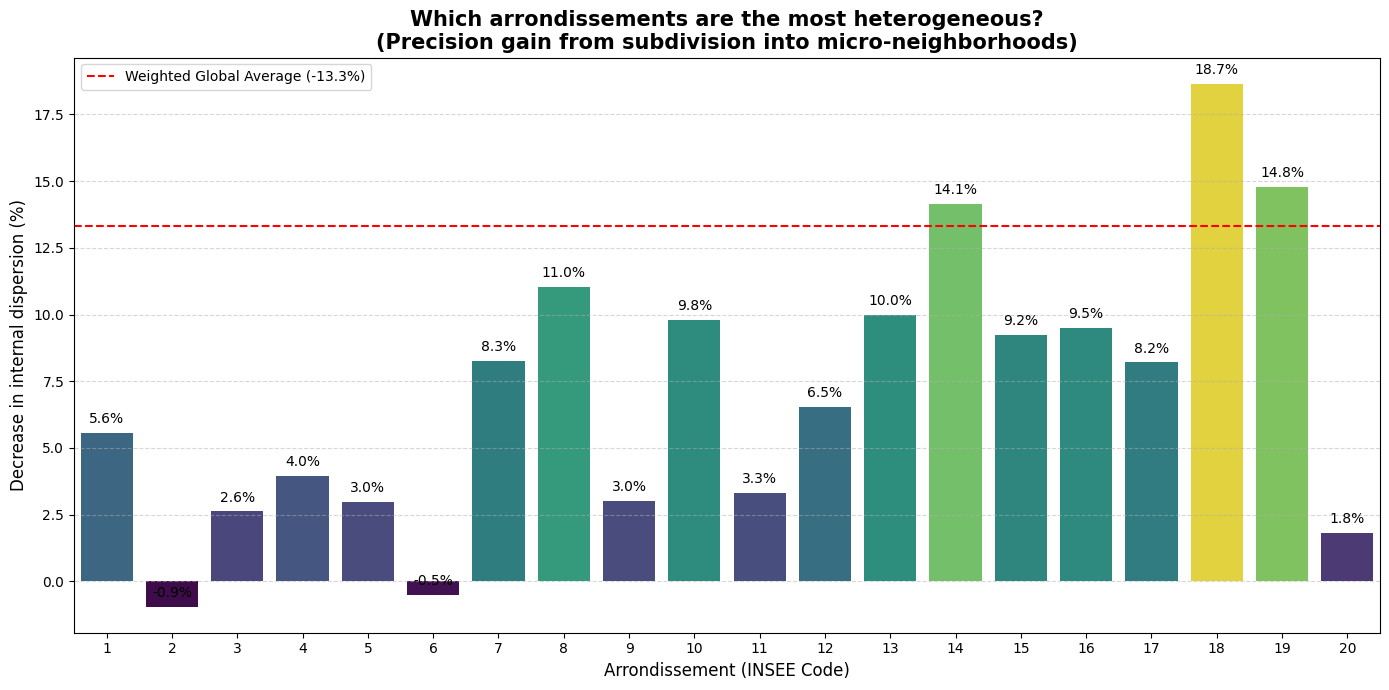

In [9]:
plt.figure(figsize=(14, 7))

# Plotting an ordered bar chart
ax = sns.barplot(
    x=analyse_heterogeneite.index, 
    y=analyse_heterogeneite['Decrease_Variance_%'], 
    palette="viridis",
    hue=analyse_heterogeneite['Decrease_Variance_%'],
    legend=False
)

plt.title("Which arrondissements are the most heterogeneous?\n(Precision gain from subdivision into micro-neighborhoods)", fontsize=15, fontweight='bold')
plt.ylabel("Decrease in internal dispersion (%)", fontsize=12)
plt.xlabel("Arrondissement (INSEE Code)", fontsize=12)
plt.axhline(baisse_variance, color='red', linestyle='--', label=f"Weighted Global Average (-{baisse_variance:.1f}%)")

# Adding values on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Explanatory power and variance decomposition (ANOVA)

We observed that micro-neighborhoods reduce dispersion error. To quantify this econometrically, we model the explanatory power of geography on price. 

We compare two regression models (Ordinary Least Squares). Scaling from 20 arrondissements to 1025 cadastral sections mechanically increases the number of variables, so to avoid any overfitting bias, we use the **Adjusted R²**, which penalizes the addition of unnecessary subdivisions.

In [10]:
import statsmodels.formula.api as smf

# 1. Model 1: Price explained by the Arrondissement
modele_arr = smf.ols('prix_m2 ~ C(arrondissement)', data=df_spatial).fit()
r2_arr = modele_arr.rsquared_adj * 100

# 2. Model 2: Price explained by the Micro-Neighborhood (Cadastral Section)
modele_sec = smf.ols('prix_m2 ~ C(micro_quartier)', data=df_spatial).fit()
r2_sec = modele_sec.rsquared_adj * 100

print("--- Variance Decomposition (Explanatory Power R²) ---")
print(f"Model 1 (Arrondissement): The arrondissement alone explains {r2_arr:.1f}% of price differences in Paris.")
print(f"Model 2 (Micro-Neighborhood): The cadastral section explains {r2_sec:.1f}% of price differences in Paris.")
print(f"-> Net information gain: +{r2_sec - r2_arr:.1f} percentage points.")

--- Variance Decomposition (Explanatory Power R²) ---
Model 1 (Arrondissement): The arrondissement alone explains 21.7% of price differences in Paris.
Model 2 (Micro-Neighborhood): The cadastral section explains 30.2% of price differences in Paris.
-> Net information gain: +8.5 percentage points.


## Conclusion of Phase 2 and Limitations

The micro-neighborhood scale increases the geographical explanatory power by approximately 40% (the adjusted R² jumps from ~21% to ~30%). Ultra-local geography thus heavily influences price formation (*the ~70% of unexplained variance logically stems from the structural characteristics of the properties: floor, condition, view, which are not present in DVF*).

**However, we reach the limit of cadastral data here:**
Although more precise, the cadastral section remains an imposed administrative boundary. It does not allow us to test for the presence of "cross-border" geographical clusters (continuous economic zones that would ignore arrondissement boundaries).

To model these endogenous economic zones, we must break free from the cadastre and perform continuous spatial clustering. This requires retrieving the exact geographical coordinates (Latitude / Longitude) of each transaction by geocoding the parcel variable (`l_idpar`).

# Phase 3: Geocoding and Cross-Border Spatial Clusters

**Objective:** Break free from administrative boundaries (arrondissements, cadastral sections) by assigning exact coordinates (Latitude / Longitude) to each transaction. This will then allow us to apply a continuous spatial clustering algorithm.

**Methodology:**
We perform a spatial join between our parcel identifier (`l_idpar`) and the official geocoded reference frame from the State (Etalab) to retrieve the centroid coordinates of each sold parcel.

In [11]:
print(f"Step 1: Loading the Etalab geocoded reference frame from the local file for the year {annee}...")

# 1. Read from disk
df_etalab = pd.read_csv(f"etalab_{annee}.csv.gz", usecols=['id_parcelle', 'longitude', 'latitude'], low_memory=False)

# 2. Creation of the coordinate dictionary
referentiel_gps = df_etalab.dropna().drop_duplicates(subset=['id_parcelle'])
print(f"Reference frame loaded: {len(referentiel_gps)} Parisian parcels.")

# 3. Cleaning the l_idpar column
def clean_idpar(val):
    try:
        if pd.isna(val): return np.nan
        if str(val).startswith('['): return ast.literal_eval(val)[0]
        return str(val)
    except: return np.nan

df_spatial['id_parcelle_clean'] = df_spatial['l_idpar'].apply(clean_idpar)

# 4. Join
df_geocoded = pd.merge(df_spatial, referentiel_gps, left_on='id_parcelle_clean', right_on='id_parcelle', how='inner')

print(f"\n--- Geocoding Summary ---")
print(f"Transactions before geocoding: {len(df_spatial)}")
print(f"Successfully geocoded transactions: {len(df_geocoded)}")
print(f"Success rate: {(len(df_geocoded)/len(df_spatial))*100:.1f} %\n")

display(df_geocoded[['id_parcelle_clean', 'prix_m2', 'micro_quartier', 'longitude', 'latitude']].head())

Step 1: Loading the Etalab geocoded reference frame from the local file for the year 2022...
Reference frame loaded: 23431 Parisian parcels.

--- Geocoding Summary ---
Transactions before geocoding: 34901
Successfully geocoded transactions: 34847
Success rate: 99.8 %



,id_parcelle_clean,prix_m2,micro_quartier,longitude,latitude
0,75116000FC0013,15555.555556,16_FC,2.291646,48.872563
1,75115000BM0057,10269.230769,15_BM,2.296429,48.835764
2,75119000AH0021,11675.000000,19_AH,2.371818,48.893530
3,75110000AO0004,10615.384615,10_AO,2.349312,48.877042
4,75114000BV0127,4166.666667,14_BV,2.328121,48.824134


## Modeling: Creation of endogenous geographic clusters (Regionalization)

To address the hypothesis of the existence of "economic borders" that break free from arrondissements (cross-borders), we apply a spatial regionalization algorithm.

**Methodology:**
1. **Algorithm:** We use Agglomerative Clustering (Ward's linkage). Unlike an unconstrained algorithm, this method allows for homogenizing price variance while imposing a strict contiguity constraint.
2. **Neighborhood graph:** In the absence of complete cadastral polygons, contiguity is approximated by a k-nearest neighbors graph (k=6) calculated on the centroids of the 1025 cadastral sections.
3. **Fair benchmark:** The algorithm generates exactly 20 clusters, allowing for a "ceteris paribus" (all else being equal) comparison with the 20 administrative arrondissements of Paris.

In [12]:
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

# 1. Data aggregation at the cadastral section scale to form continuous spatial units
df_sections = df_geocoded.groupby('micro_quartier').agg({
    'prix_m2': 'mean',
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

# 2. Creation of the contiguity graph on the 1025 sections
coordonnees_sec = df_sections[['latitude', 'longitude']].values
# k=6 approximates the natural geographic neighborhood (like hexagons)
graphe_sec = kneighbors_graph(coordonnees_sec, n_neighbors=6, include_self=False)

# 3. Strict spatial regionalization into 20 zones
scaler = StandardScaler()
prix_sec_scaled = scaler.fit_transform(df_sections[['prix_m2']])

nombre_de_clusters = 20
modele_spatial = AgglomerativeClustering(
    n_clusters=nombre_de_clusters,
    connectivity=graphe_sec,
    linkage='ward'
)
df_sections['cluster_eco'] = modele_spatial.fit_predict(prix_sec_scaled)

# 4. Projection onto the 34,000 transactions
if 'cluster_eco' in df_geocoded.columns:
    df_geocoded = df_geocoded.drop(columns=['cluster_eco'])
df_geocoded = pd.merge(df_geocoded, df_sections[['micro_quartier', 'cluster_eco']], on='micro_quartier', how='left')

# Calculation of R²
ols_clusters = smf.ols('prix_m2 ~ C(cluster_eco)', data=df_geocoded).fit()
r2_clusters_adj = ols_clusters.rsquared_adj * 100

print("\n20 ARRONDISSEMENTS vs 20 NEW CLUSTERS ---")
print(f"Arrondissements R² (20 administrative zones): 21.7 %")
print(f"Endogenous Clusters R² (20 market zones): {r2_clusters_adj:.1f} %")


20 ARRONDISSEMENTS vs 20 NEW CLUSTERS ---
Arrondissements R² (20 administrative zones): 21.7 %
Endogenous Clusters R² (20 market zones): 27.9 %


In [13]:
import folium
import matplotlib.cm as cm
import matplotlib.colors as colors

print("Generating the interactive map of Paris with boundary overlay...")

# 1. Creating the basemap centered on Paris
map_paris = folium.Map(location=[48.8566, 2.3422], zoom_start=12, tiles='CartoDB positron', prefer_canvas=True)

# 2. Creating a palette of 20 unique colors
colormap = cm.get_cmap('gist_ncar', nombre_de_clusters)
def get_color(cluster_id):
    rgba = colormap(cluster_id)
    return colors.to_hex(rgba)

# 3. Adding colored transactions by new economic cluster
for idx, row in df_geocoded.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2, # Small dots to clearly see density
        color=get_color(row['cluster_eco']),
        fill=True,
        fill_color=get_color(row['cluster_eco']),
        fill_opacity=0.7,
        stroke=False
    ).add_to(map_paris)

# 4. Adding the official INSEE boundaries (Open Data Paris)
url_arrondissements = "https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/arrondissements/exports/geojson?lang=fr&timezone=Europe%2FBerlin"

folium.GeoJson(
    url_arrondissements,
    name="Administrative Boundaries (INSEE)",
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',       # Black lines
        'weight': 3,            # Line thickness
        'dashArray': '5, 5'     # Dashed lines to clearly see spillovers
    }
).add_to(map_paris)

print("Map generated! (Display 'map_paris' to view)")
# display(map_paris)

Generating the interactive map of Paris with boundary overlay...


C:\Users\sylva\AppData\Local\Temp\ipykernel_30088\74878115.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('gist_ncar', nombre_de_clusters)


Map generated! (Display 'map_paris' to view)


The interactive map above projects our 20 endogenous economic clusters (colored zones) onto the real topography of Paris, superimposed over the INSEE boundaries (dashed black lines). With an equal number of zones, this zoning explains 27.9% of the price variance, compared to 21.7% for the administrative one.

This modeling reveals several major phenomena:
* **Evidence of spillover (Cross-border):** The market creates continuous pockets that span across official INSEE boundaries, particularly visible in eastern Paris (e.g., 10th/11th/12th).
* **The fracturing of large arrondissements:** The 15th and 16th arrondissements no longer appear as homogeneous blocks. The algorithm splits them and even creates unexpected continuities, for example between the 15th and 14th arrondissements, proving that the border between the two is economically porous.
* **The central macro-market:** Conversely, the algorithm tends to merge the small historical central arrondissements (1st, 2nd, 3rd), which behave as a single economic zone.

---

*Methodological note: Using a contiguity graph based on GPS centroids (k=6) instead of strict polygons (Rook/Queen) can visually create slight overlaps or small "bridges" over physical barriers like the Seine River. This is an artifact of geometric representation that does not invalidate the overall explanatory power of the regionalization.*

# General Conclusion (Phases 1-3)

The administrative boundaries of Paris (arrondissements) therefore constitute a sub-optimal grid for real estate market analysis.

**Summary of results:**
1. **Administrative inadequacy:** Scaling down to the micro-neighborhood level represented by the cadastral section reduces price dispersion by 13.3% and improves geographical explanatory power (adjusted R²) by nearly 40%.
2. **The weight of endogenous clusters:** Modeling via constrained spatial regionalization generated 20 natural economic zones. **This new grid achieves an explanatory power (adjusted R²) of 27.9 %, significantly outperforming the 21.7 % of the 20 official arrondissements.** The economy thus has its own borders.
3. **Structural limitations:** About 70% of the variance remains unexplained by pure geography, which points back to the intrinsic characteristics of properties (floor, condition, view) absent from the DVF data.

---
*Note on modeling: The clusters' R² calculated here is an "in-sample" measure (the algorithm optimized the partition on the same data used for evaluation). This method would require cross-validation ("out-of-sample") to confirm the strict robustness of our metric.*

# Phase 4: Temporal Robustness and Methodological Validation (Appendix)

Following the initial results demonstrating the relevance of endogenous clusters for the year 2022, this section aims to test the solidity of the spatial model through two robustness tests:

1. **Data massification (2021-2024):** To increase statistical power and smooth out micro-liquidity effects (lack of transactions in certain streets over an isolated year), we merge four years of transactions.
2. **K-discipline (Number of clusters):** Instead of imposing $k=20$ to match the administrative zoning, we seek the optimal number of economic zones through internal validation (Silhouette Score and Calinski-Harabasz Index).

The goal is to identify the "natural" geographical structure of the Parisian real estate market.

In [14]:
print("Step 1: Preparation of the extended dataset (Cerema + GPS Etalab) for 2021-2024...")

# 1. Start from df_clean keeping 2021-2024
df_spatial_multi = df_clean[df_clean['anneemut'].isin(annees_disponibles)].copy()

# 2. Reproduction of Phase 2 processing
df_spatial_multi['section'] = df_spatial_multi['l_section'].apply(lambda x: ast.literal_eval(x)[0] if pd.notna(x) else np.nan)
df_spatial_multi['arrondissement'] = df_spatial_multi['l_codinsee'].apply(lambda x: int(ast.literal_eval(x)[0][-2:]) if pd.notna(x) else None)
df_spatial_multi = df_spatial_multi.dropna(subset=['arrondissement', 'section'])
df_spatial_multi['micro_quartier'] = df_spatial_multi['arrondissement'].astype(str) + "_" + df_spatial_multi['section']
df_spatial_multi = df_spatial_multi.groupby('micro_quartier').filter(lambda x: len(x) >= 5)

print(f"\n--- Scope of the aggregated spatial analysis ---")
print(f"Number of transactions studied: {len(df_spatial_multi)}")
print(f"Number of micro-neighborhoods (Sections) studied: {df_spatial_multi['micro_quartier'].nunique()}")

# 3. Reproduction of Phase 3 processing
df_spatial_multi['id_parcelle_clean'] = df_spatial_multi['l_idpar'].apply(
    lambda x: ast.literal_eval(x)[0] if pd.notna(x) and str(x).startswith('[') else (str(x) if pd.notna(x) else np.nan)
)

print(f"Cleaned Cerema transactions ready: {len(df_spatial_multi)}")

dfs_gps = []
for a in annees_disponibles:
    print(f" -> Loading Etalab GPS {a}...")
    df_temp_gps = pd.read_csv(f"etalab_{a}.csv.gz", usecols=['id_parcelle', 'longitude', 'latitude'], low_memory=False)
    dfs_gps.append(df_temp_gps)

referentiel_gps_multi = pd.concat(dfs_gps, ignore_index=True).dropna().drop_duplicates(subset=['id_parcelle'])

df_geocoded_multi = pd.merge(df_spatial_multi, referentiel_gps_multi, left_on='id_parcelle_clean', right_on='id_parcelle', how='inner')
print(f"Multi-year Geocoding Summary: {len(df_geocoded_multi)} transactions successfully geolocated.")

df_sections_multi = df_geocoded_multi.groupby('micro_quartier').agg({
    'prix_m2': 'mean',
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

print(f"Finalized spatial database: {len(df_sections_multi)} dense micro-neighborhoods ready for mapping.")

Step 1: Preparation of the extended dataset (Cerema + GPS Etalab) for 2021-2024...

--- Scope of the aggregated spatial analysis ---
Number of transactions studied: 120890
Number of micro-neighborhoods (Sections) studied: 1093
Cleaned Cerema transactions ready: 120890
 -> Loading Etalab GPS 2021...
 -> Loading Etalab GPS 2022...
 -> Loading Etalab GPS 2023...
 -> Loading Etalab GPS 2024...
Multi-year Geocoding Summary: 120711 transactions successfully geolocated.
Finalized spatial database: 1093 dense micro-neighborhoods ready for mapping.


In [15]:
print("Step 2: Spatial regionalization and calculation of consolidated R² (2021-2024)...")

# 1. Spatial graph on dense sections
coordonnees_multi = df_sections_multi[['latitude', 'longitude']].values
graphe_multi = kneighbors_graph(coordonnees_multi, n_neighbors=6, include_self=False)

# 2. Scaling and algorithm
scaler_multi = StandardScaler()
prix_multi_scaled = scaler_multi.fit_transform(df_sections_multi[['prix_m2']])

nombre_de_clusters_multi = 20
modele_spatial_multi = AgglomerativeClustering(
    n_clusters=nombre_de_clusters_multi,
    connectivity=graphe_multi,
    linkage='ward'
)
df_sections_multi['cluster_eco_multi'] = modele_spatial_multi.fit_predict(prix_multi_scaled)

# 3. Projection onto the transactional database
df_geocoded_multi = pd.merge(
    df_geocoded_multi, 
    df_sections_multi[['micro_quartier', 'cluster_eco_multi']], 
    on='micro_quartier', 
    how='left'
)

# 4. Calculation of consolidated R²
ols_clusters_multi = smf.ols('prix_m2 ~ C(cluster_eco_multi)', data=df_geocoded_multi).fit()
r2_clusters_multi_adj = ols_clusters_multi.rsquared_adj * 100

print("\n--- MULTI-YEAR ROBUSTNESS SUMMARY ---")
print(f"Consolidated Endogenous Clusters R² (20 zones): {r2_clusters_multi_adj:.1f} %")

Step 2: Spatial regionalization and calculation of consolidated R² (2021-2024)...

--- MULTI-YEAR ROBUSTNESS SUMMARY ---
Consolidated Endogenous Clusters R² (20 zones): 26.7 %


In [16]:
print("Step 3: Generating the global interactive map...")

# Color alignment between the two partitions (Phase 3 vs Phase 4)
df_mapping = pd.merge(
    df_sections_multi[['micro_quartier', 'cluster_eco_multi']],
    df_sections[['micro_quartier', 'cluster_eco']], # cluster_eco = the one from Phase 3
    on='micro_quartier', 
    how='inner'
)
mapping_dict = df_mapping.groupby('cluster_eco_multi')['cluster_eco'].agg(lambda x: x.value_counts().index[0]).to_dict()
df_sections_multi['cluster_eco_aligne'] = df_sections_multi['cluster_eco_multi'].map(mapping_dict)
if 'cluster_eco_aligne' in df_geocoded_multi.columns:
    df_geocoded_multi = df_geocoded_multi.drop(columns=['cluster_eco_aligne'])
df_geocoded_multi = pd.merge(df_geocoded_multi, df_sections_multi[['micro_quartier', 'cluster_eco_aligne']], on='micro_quartier', how='left')

map_paris_multi = folium.Map(location=[48.8566, 2.3422], zoom_start=12, tiles='CartoDB positron', prefer_canvas=True)

# Multi-year dense scatter plot
for idx, row in df_geocoded_multi.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color=get_color(row['cluster_eco_aligne']),
        fill=True,
        fill_color=get_color(row['cluster_eco_aligne']),
        fill_opacity=0.7,
        stroke=False
    ).add_to(map_paris_multi)

folium.GeoJson(
    url_arrondissements,
    name="Administrative Boundaries (INSEE)",
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 3,
        'dashArray': '5, 5'
    }
).add_to(map_paris_multi)

print("Map generated! (Display 'map_paris_multi' to view)")
# display(map_paris_multi)

Step 3: Generating the global interactive map...
Map generated! (Display 'map_paris_multi' to view)


In [17]:
print("Step 4: Generating the consolidated map by micro-neighborhoods...")

map_paris_sections = folium.Map(location=[48.8566, 2.3422], zoom_start=12, tiles='CartoDB positron', prefer_canvas=True)

# Sections instead of individual transactions for optimal readability
for idx, row in df_sections_multi.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4, # Larger than transactions
        color=get_color(row['cluster_eco_aligne']),
        fill=True,
        fill_color=get_color(row['cluster_eco_aligne']),
        fill_opacity=0.8,
        stroke=False,
        tooltip=f"Average price: {row['prix_m2']:.0f} €/sq.m"
    ).add_to(map_paris_sections)

folium.GeoJson(
    url_arrondissements,
    name="Administrative Boundaries",
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 3,
        'dashArray': '5, 5'
    }
).add_to(map_paris_sections)

print("Map generated! (Display 'map_paris_sections' to view)")
# display(map_paris_sections)

Step 4: Generating the consolidated map by micro-neighborhoods...
Map generated! (Display 'map_paris_sections' to view)


To determine the optimal number of spatial structures for the Parisian market, we vary $k$ from 10 to 35 within the regionalization algorithm. We analyze two types of signals:

* **Classic statistical criteria (Silhouette & Calinski-Harabasz):** Evaluate the geometric separation of the groups.
* **Econometric trade-off (Adjusted R² vs. Minimum cluster size):** Evaluates the gain in explanatory precision against the risk of overfitting and economic instability of micro-markets.

K Discipline...


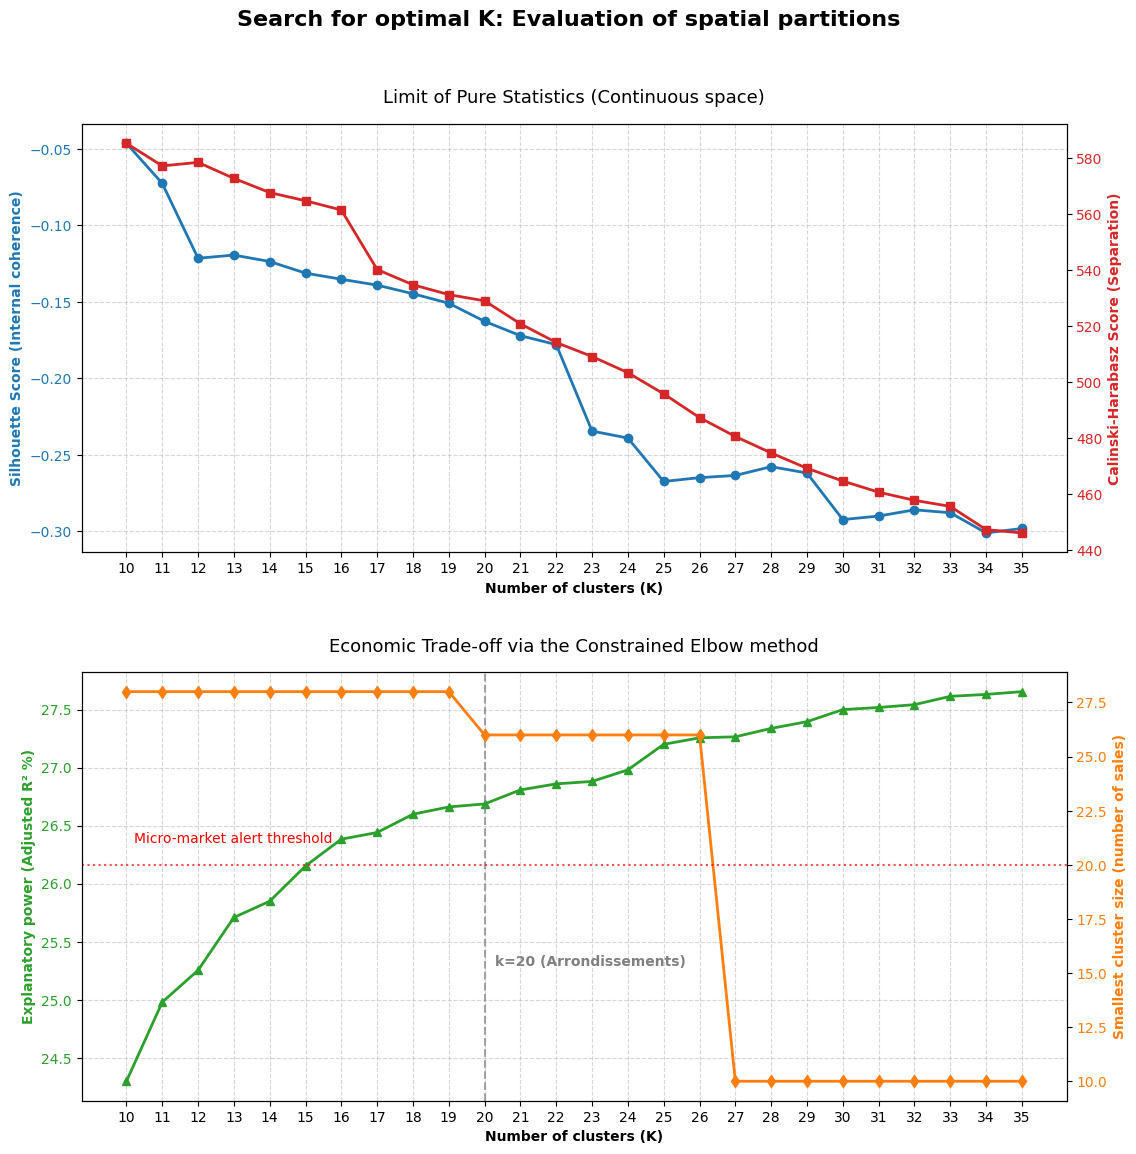

In [18]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

print("K Discipline...")

plage_k = range(10, 36)
silhouettes = []
calinskis = []
r2_scores = []
min_cluster_sizes = []

total_transactions = len(df_geocoded_multi)

for k in plage_k:
    model = AgglomerativeClustering(n_clusters=k, connectivity=graphe_multi, linkage='ward')
    labels = model.fit_predict(prix_multi_scaled)
    df_sections_multi[f'cluster_temp_{k}'] = labels
    
    # Statistical metrics
    silhouettes.append(silhouette_score(prix_multi_scaled, labels))
    calinskis.append(calinski_harabasz_score(prix_multi_scaled, labels))

    # Projection onto transactions to calculate R²
    df_temp = pd.merge(
        df_geocoded_multi[['prix_m2', 'micro_quartier']], 
        df_sections_multi[['micro_quartier', f'cluster_temp_{k}']], 
        on='micro_quartier', 
        how='inner'
    )

    # Size of the smallest cluster (in % of Parisian sales)
    taille_min = df_temp[f'cluster_temp_{k}'].value_counts().min()
    min_cluster_sizes.append(taille_min)
    
    # Calculation of explanatory power (R²)
    ols_temp = smf.ols(f'prix_m2 ~ C(cluster_temp_{k})', data=df_temp).fit()
    r2_scores.append(ols_temp.rsquared_adj * 100)

# Visualization
fig, (ax_stat, ax_eco) = plt.subplots(2, 1, figsize=(12, 12))

# Coherence and separation statistics
ax_stat.set_xticks(plage_k)
ax_stat.set_xlabel('Number of clusters (K)', fontweight='bold')
ax_stat.set_ylabel('Silhouette Score (Internal coherence)', color='tab:blue', fontweight='bold')
ax_stat.plot(plage_k, silhouettes, marker='o', color='tab:blue', linewidth=2)
ax_stat.tick_params(axis='y', labelcolor='tab:blue')

ax_stat_2 = ax_stat.twinx()  
ax_stat_2.set_ylabel('Calinski-Harabasz Score (Separation)', color='tab:red', fontweight='bold')  
ax_stat_2.plot(plage_k, calinskis, marker='s', color='tab:red', linewidth=2)
ax_stat_2.tick_params(axis='y', labelcolor='tab:red')

ax_stat.set_title("Limit of Pure Statistics (Continuous space)", fontsize=13, pad=15)
ax_stat.grid(True, linestyle='--', alpha=0.5)

# Explanatory power and cluster size
ax_eco.set_xticks(plage_k)
ax_eco.set_xlabel('Number of clusters (K)', fontweight='bold')
ax_eco.set_ylabel('Explanatory power (Adjusted R² %)', color='tab:green', fontweight='bold')
ax_eco.plot(plage_k, r2_scores, marker='^', color='tab:green', linewidth=2)
ax_eco.tick_params(axis='y', labelcolor='tab:green')

# Marking K=20 (our interpretable choice)
ax_eco.axvline(x=20, color='gray', linestyle='--', alpha=0.7)
ax_eco.text(20.3, min(r2_scores) + 1, "k=20 (Arrondissements)", color='gray', fontweight='bold')

ax_eco_2 = ax_eco.twinx()  
ax_eco_2.set_ylabel('Smallest cluster size (number of sales)', color='tab:orange', fontweight='bold')  
ax_eco_2.plot(plage_k, min_cluster_sizes, marker='d', color='tab:orange', linewidth=2)
ax_eco_2.tick_params(axis='y', labelcolor='tab:orange')

# Adding an economic viability threshold (e.g., 20 transactions)
seuil = 20
ax_eco_2.axhline(y=seuil, color='red', linestyle=':', alpha=0.7)
ax_eco_2.text(10.2, 21, "Micro-market alert threshold", color='red')

ax_eco.set_title("Economic Trade-off via the Constrained Elbow method", fontsize=13, pad=15)
ax_eco.grid(True, linestyle='--', alpha=0.5)

fig.suptitle("Search for optimal K: Evaluation of spatial partitions", fontsize=16, fontweight='bold', y=0.98)
fig.tight_layout(pad=3.0)  
plt.show()

## Conclusion of phase 4

An in-depth examination of the indicators yields fundamental methodological conclusions:

1. **Failure of pure statistics (Continuous gradient):** The Silhouette and Calinski-Harabasz coefficients are decreasing. In a dense urban space like Paris, prices form a continuous spatial gradient (East/West) rather than "islands" isolated by emptiness. Pure statistics reject borders and attempt to maintain a binary macro-unit, which is unexploitable at a local scale.
2. **Validation of the Economic Elbow:** The adjusted $R^2$ exhibits a concave shape with an inflection point (diminishing marginal returns) located around $k=18$. Beyond $k=21$, multiplying clusters provides no substantial gain in explanatory power.
3. **The precipice of instability ($k=27$):** Analysis of the minimum size reveals that starting from $k=27$, the algorithm isolates a residual micro-market of only 10 transactions over 4 years, crossing the critical threshold of statistical viability.

**Final trade-off:** The exogenous constraint $k=20$ is located exactly in the optimal performance zone for R² (26.7 %), preserves the statistical density of each sub-market, and ensures perfect comparability with the administrative grid of the 20 arrondissements.